In [24]:
!pip install wordcloud

In [25]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

In [27]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [28]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [29]:
df['sentiment'] = df['sentiment'].str.strip().str.lower()

df['sentiment'] = df['sentiment'].map({
    'positive':1,
    'negative':0
})

In [30]:
df['sentiment'].value_counts()

sentiment
1    25000
0    25000
Name: count, dtype: int64

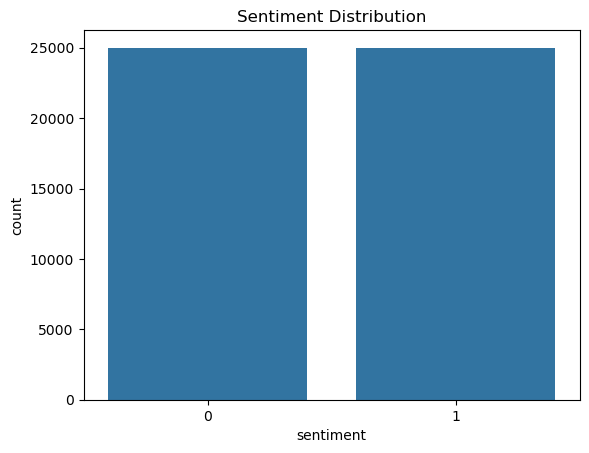

In [31]:
sns.countplot(x=df['sentiment'])
plt.title("Sentiment Distribution")
plt.show()

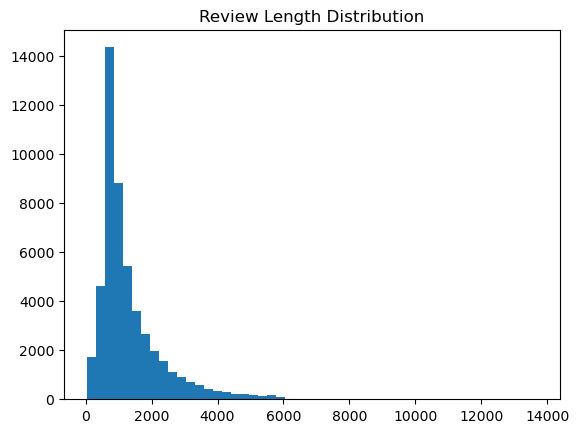

In [32]:
df['review_length'] = df['review'].apply(len)

plt.hist(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()

In [33]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [34]:
stop_words = set(stopwords.words('english'))

In [35]:
def clean_text(text):

    text = text.lower()
    text = re.sub(r"<.*?>"," ",text)
    text = re.sub(r"[^a-zA-Z]"," ",text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [36]:
df['clean_review'] = df['review'].apply(clean_text)

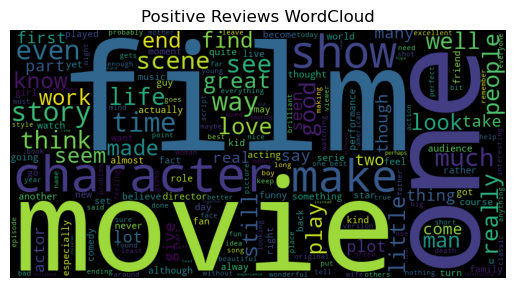

In [37]:
positive_text = " ".join(df[df['sentiment']==1]['clean_review'])

wordcloud = WordCloud(width=800,height=400).generate(positive_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()

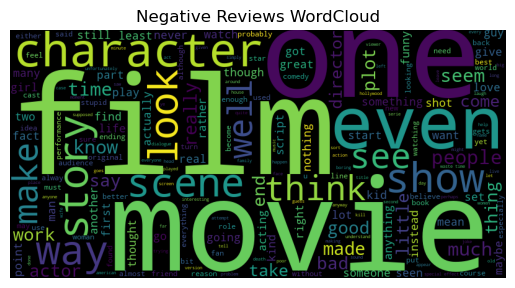

In [39]:
negative_text = " ".join(df[df['sentiment']==0]['clean_review'])

wordcloud = WordCloud(width=800,height=400,background_color="black").generate(negative_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Negative Reviews WordCloud")
plt.show()

In [40]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df['clean_review'])

y = df['sentiment']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [43]:
y_pred = model.predict(X_test)

In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



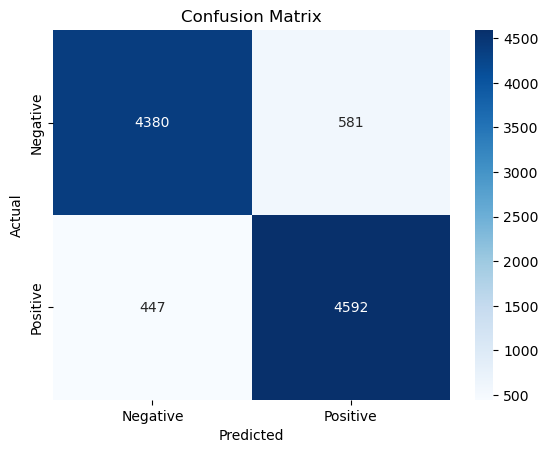

In [45]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Positive"],
            yticklabels=["Negative","Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [46]:
def predict_sentiment(review):

    review = clean_text(review)

    vector = tfidf.transform([review])

    prediction = model.predict(vector)

    if prediction[0] == 1:
        return "Positive 😀"
    else:
        return "Negative 😡"

In [47]:
predict_sentiment("This movie was amazing and I loved it")

'Positive 😀'

In [48]:
predict_sentiment("Worst movie ever. Completely boring")

'Negative 😡'

In [49]:
import pickle

pickle.dump(model, open("sentiment_model.pkl","wb"))
pickle.dump(tfidf, open("tfidf_vectorizer.pkl","wb"))